# Credit Risk — Exploratory Data Analysis
Runs full EDA on the **cleaned** dataset produced by `data_prep.ipynb`.

> ⚠️ Run `data_prep.ipynb` first to generate `data/clean_cs_training.csv`.

In [28]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load Cleaned Data

In [29]:
# Load the clean CSV saved by data_prep.ipynb
data_path = os.path.abspath(os.path.join('..', 'data', 'clean_cs_training.csv'))
df = pd.read_csv(data_path)

TARGET   = 'default'
FEATURES = [c for c in df.columns if c != TARGET]

print(f'Loaded : {data_path}')
print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded : c:\Users\ARWA\credit_risk_predictor\data\clean_cs_training.csv
Shape  : 150,000 rows x 11 columns
Columns: ['util_rate', 'age', 'late_30_59', 'debt_ratio', 'income', 'open_loans', 'late_90_plus', 'real_estate_loans', 'late_60_89', 'dependents', 'default']


,util_rate,age,late_30_59,debt_ratio,income,open_loans,late_90_plus,real_estate_loans,late_60_89,dependents,default
0,1.156407,-0.318182,2.0,0.629670,1.063769,0.833333,0.0,2.5,0.0,2.0,1
1,1.517389,-0.545455,0.0,-0.352912,-0.800686,-0.666667,0.0,-0.5,0.0,1.0,0
2,0.952418,-0.636364,1.0,-0.405947,-0.674292,-1.000000,1.0,-0.5,0.0,0.0,0
3,0.150477,-1.000000,0.0,-0.476728,-0.600515,-0.500000,0.0,-0.5,0.0,0.0,0
4,1.423070,-0.136364,1.0,-0.492776,16.639405,-0.166667,0.0,0.0,0.0,0.0,0


## 2. Data Overview

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   util_rate          150000 non-null  float64
 1   age                150000 non-null  float64
 2   late_30_59         150000 non-null  float64
 3   debt_ratio         150000 non-null  float64
 4   income             150000 non-null  float64
 5   open_loans         150000 non-null  float64
 6   late_90_plus       150000 non-null  float64
 7   real_estate_loans  150000 non-null  float64
 8   late_60_89         150000 non-null  float64
 9   dependents         150000 non-null  float64
 10  default            150000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 12.6 MB


In [31]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
util_rate,150000.0,11.138,471.968,-0.291,-0.235,-0.0,0.765,95823.652
age,150000.0,0.013,0.671,-1.409,-0.500,0.0,0.500,2.591
late_30_59,150000.0,0.421,4.193,0.000,0.000,0.0,0.000,98.000
debt_ratio,150000.0,508.726,2939.812,-0.529,-0.276,0.0,0.724,475581.612
income,150000.0,0.291,3.686,-1.544,-0.428,0.0,0.572,858.836
open_loans,150000.0,0.075,0.858,-1.333,-0.500,0.0,0.500,8.333
late_90_plus,150000.0,0.266,4.169,0.000,0.000,0.0,0.000,98.000
real_estate_loans,150000.0,0.009,0.565,-0.500,-0.500,0.0,0.500,26.500
late_60_89,150000.0,0.240,4.155,0.000,0.000,0.0,0.000,98.000
dependents,150000.0,0.737,1.107,0.000,0.000,0.0,1.000,20.000


In [32]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_found = missing[missing['Missing Count'] > 0]
if missing_found.empty:
    print('No missing values — data is clean!')


No missing values — data is clean!


## 3. Target Analysis


default
0    139974
1     10026
Name: count, dtype: int64

Default rate: 0.06684


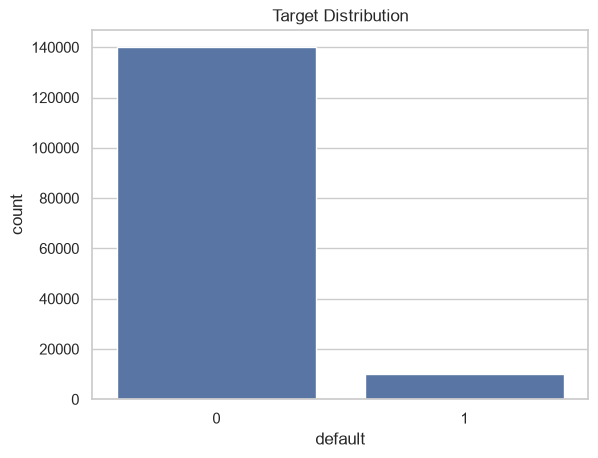

In [33]:
print(df[TARGET].value_counts())
print('\nDefault rate:', df[TARGET].mean())
sns.countplot(x=TARGET, data=df)
plt.title("Target Distribution")
plt.show()

this means we have imbalance data , so we have to choose the MLmodel which work well with the imbalance data like RandomForest 

## 4. Basic Data Quality Check


In [34]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("Duplicates:", df.duplicated().sum())

Missing values:
util_rate            0
age                  0
late_30_59           0
debt_ratio           0
income               0
open_loans           0
late_90_plus         0
real_estate_loans    0
late_60_89           0
dependents           0
default              0
dtype: int64
Duplicates: 767


In [26]:
df = df.drop_duplicates()

## 5. Quick Statistics Overview


In [17]:
df.describe().T
print(df.skew(numeric_only=True).sort_values(ascending=False))

income               127.121696
util_rate             97.631574
debt_ratio            95.157793
late_60_89            23.331743
late_90_plus          23.087345
late_30_59            22.597108
real_estate_loans      3.482484
default                3.468857
dependents             1.626059
open_loans             1.215314
age                    0.189244
dtype: float64


high skewness so we need to use Tree-Based Models
not sensetive to skewness



## 6. Distribution of Features


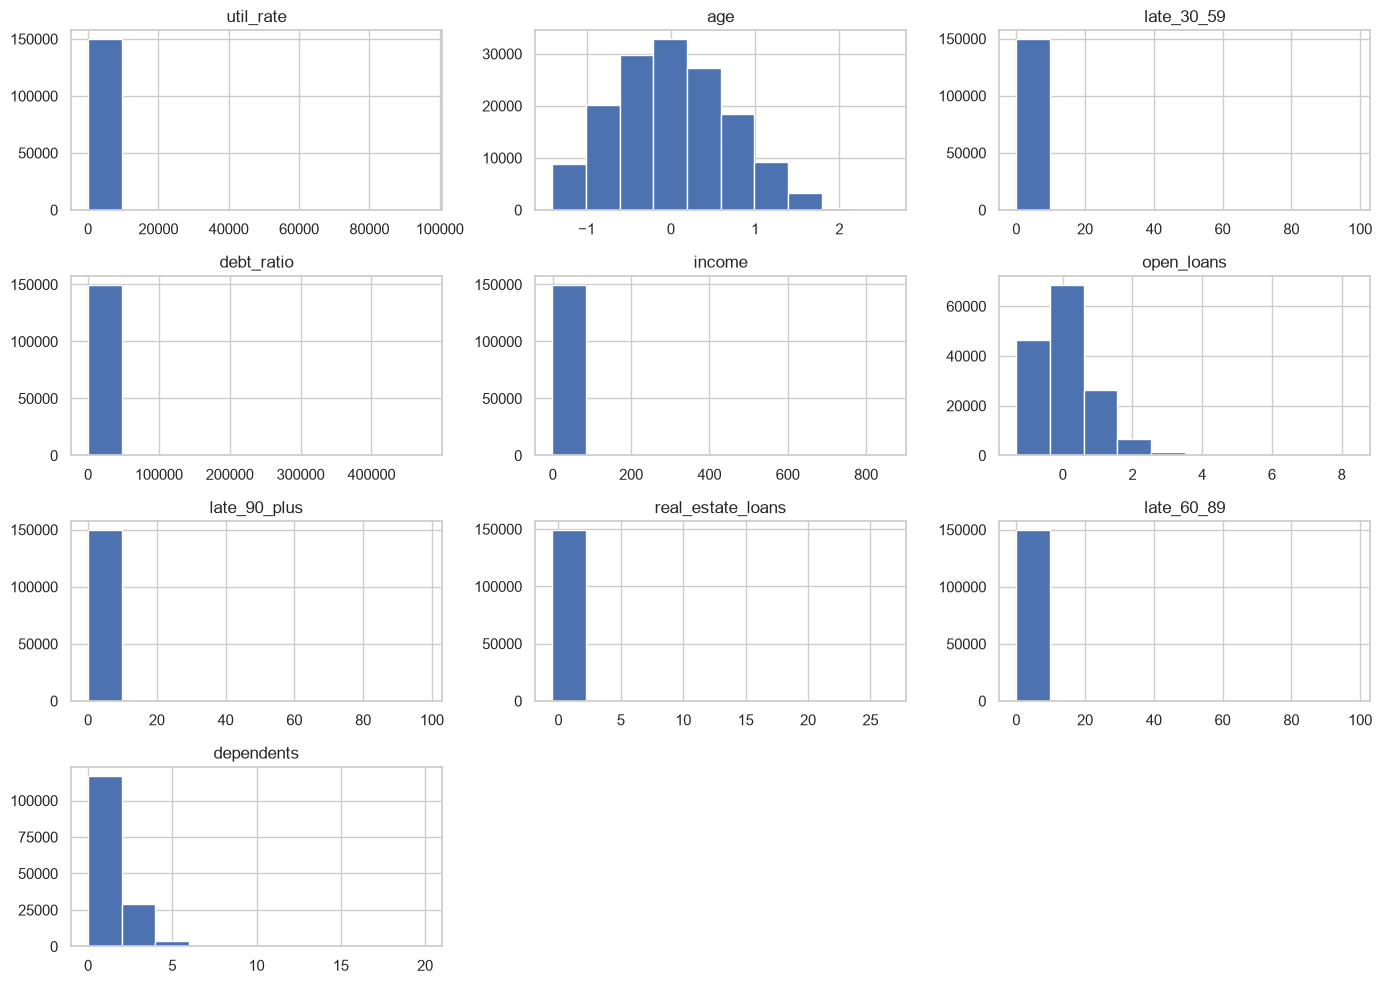

In [18]:
df[FEATURES].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## 7. Correlation Analysis


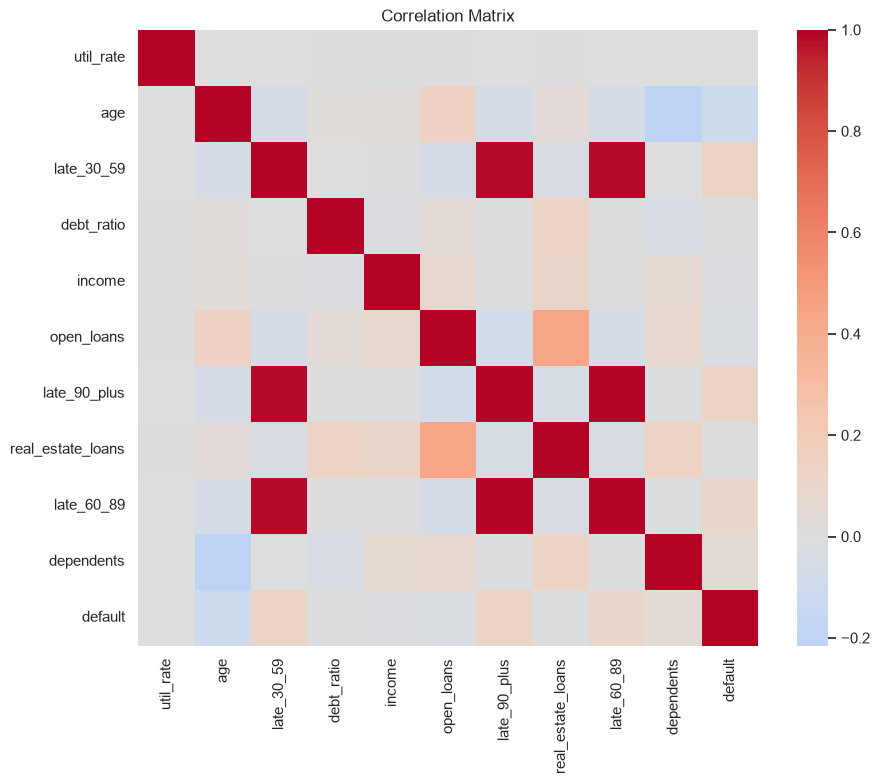

default              1.000000
late_30_59           0.125587
late_90_plus         0.117175
late_60_89           0.102261
dependents           0.046869
util_rate           -0.001802
real_estate_loans   -0.007038
debt_ratio          -0.007602
income              -0.017151
open_loans          -0.029669
age                 -0.115397
Name: default, dtype: float64

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()
corr[TARGET].sort_values(ascending=False)

كل ما التأخير يزيد → probability of default يزيد

كل ما السن يزيد → default يقل


we have to make combine features between late_30_59
late_60_89
late_90_plus because they are correlated

In [35]:
df['total_late'] = df['late_30_59'] + df['late_60_89'] + df['late_90_plus']

## 8. Feature vs Target Analysis

In [36]:
for col in FEATURES:
    print("\n", col)
    print(df.groupby(TARGET)[col].mean())


 util_rate
default
0    11.366053
1     7.961583
Name: util_rate, dtype: float64

 age
default
0    0.034170
1   -0.276064
Name: age, dtype: float64

 late_30_59
default
0    0.280109
1    2.388490
Name: late_30_59, dtype: float64

 debt_ratio
default
0    514.707133
1    425.220843
Name: debt_ratio, dtype: float64

 income
default
0    0.308156
1    0.055019
Name: income, dtype: float64

 open_loans
default
0    0.082270
1   -0.019616
Name: open_loans, dtype: float64

 late_90_plus
default
0    0.135225
1    2.091362
Name: late_90_plus, dtype: float64

 real_estate_loans
default
0    0.010184
1   -0.005735
Name: real_estate_loans, dtype: float64

 late_60_89
default
0    0.126666
1    1.828047
Name: late_60_89, dtype: float64

 dependents
default
0    0.723527
1    0.931279
Name: dependents, dtype: float64


## 9. Outlier Detection (IQR)

In [39]:
outlier_summary = []

for col in FEATURES:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "feature": col,
        "outliers_count": len(outliers),
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,outliers_count,lower_bound,upper_bound
0,util_rate,763,-1.734917,2.265083
1,age,45,-2.000000,2.000000
2,late_30_59,23982,0.000000,0.000000
3,debt_ratio,31311,-1.776168,2.223832
4,income,9149,-1.928081,2.071919
5,open_loans,3980,-2.000000,2.000000
6,late_90_plus,8338,0.000000,0.000000
7,real_estate_loans,793,-2.000000,2.000000
8,late_60_89,7604,0.000000,0.000000
9,dependents,13336,-1.500000,2.500000


outliers = high risk customers 
outliers are not problem

## 10.Binning Analysis 


age_bin
(0, 30]    0.040603
Name: default, dtype: float64


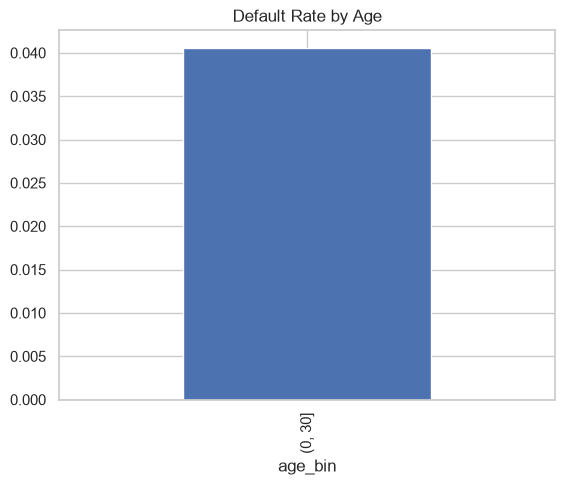

In [23]:
df['age_bin'] = pd.cut(df['age'], bins=[0,30,45,60,100])

age_default = df.groupby('age_bin')[TARGET].mean()

print(age_default)

age_default.plot(kind='bar')
plt.title("Default Rate by Age")
plt.show()

under 30 = high risk

## 11.Aggregated Features Insight

In [24]:
df['total_late'] = df['late_30_59'] + df['late_60_89']

print(df.groupby(TARGET)['total_late'].mean())

default
0    0.406776
1    4.216537
Name: total_late, dtype: float64


## 12.Class Imbalance Confirmation

In [25]:
df[TARGET].value_counts(normalize=True)

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64